In [22]:
# NumPy: fundamental package for numerical operations (arrays, linear algebra, etc.)
import numpy as np

# Matplotlib: plotting library; pyplot provides a MATLAB-style interface for creating figures and charts
import matplotlib.pyplot as plt

# Pandas: powerful data manipulation library; DataFrame API for loading, cleaning, and analyzing tabular data
import pandas as pd

# Seaborn: high-level statistical visualization library built on top of Matplotlib
import seaborn as sns

In [23]:
# Read the customer data from the CSV file into a pandas DataFrame
dataset = pd.read_csv('Mall_Customers.csv')

In [24]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [25]:
# Select the 4th and 5th columns (Annual Income and Spending Score) as a NumPy array 
X = dataset.iloc[:, 3:5].values

In [26]:
# Display the entire array of Annual Income and Spending Score for each customer
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

C:\Users\mukil\anaconda3\envs\aiml\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mukil\anaconda3\envs\aiml\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mukil\anaconda3\envs\aiml\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mukil\anaconda3\envs\aiml\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans 

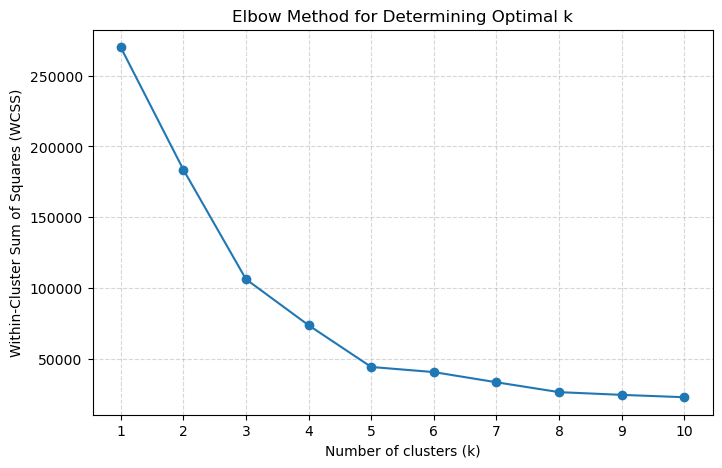

In [27]:
from sklearn.cluster import KMeans  # KMeans clustering algorithm

# Prepare a list to hold the Within-Cluster Sum of Squares (WCSS) for each k
wcss = []

# Try cluster counts from 1 to 10
for k in range(1, 11):
    # Initialize KMeans:
    # n_clusters=k        → how many clusters to form
    # init='k-means++'    → smart centroid initialization for faster convergence
    # random_state=42     → fixed seed for reproducibility
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    
    # Fit to our data (X) and compute cluster centroids
    kmeans.fit(X)
    
    # .inertia_ is the WCSS: sum of squared distances of samples to their closest centroid
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))                # Optional: set a figure size
plt.plot(range(1, 11), wcss, marker='o')  # Plot WCSS vs. number of clusters
plt.title('Elbow Method for Determining Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))                  # Show ticks for each integer k
plt.grid(True, linestyle='--', alpha=0.5) # Optional: add a light grid
plt.show()

In [28]:
# Import the KMeans class from scikit-learn’s clustering module
from sklearn.cluster import KMeans  

# Initialize KMeans:
# - n_clusters=5       → ask for 5 clusters
# - init='k-means++'   → smart centroid seeding to speed up convergence
# - random_state=42    → fixed seed so results are reproducible
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

# Fit the model to X and predict cluster membership for each point in one step:
# - .fit_predict(...) returns an array of cluster labels, shape (n_samples,)
y_kmeans = kmeans.fit_predict(X)

C:\Users\mukil\anaconda3\envs\aiml\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [29]:
# Display the array of cluster labels assigned to each sample
y_kmeans

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [30]:
# Create a copy of the original DataFrame so we can add cluster labels without altering the raw data
supervised = dataset.copy()

In [31]:
# Make a deep copy of the original DataFrame so that any further modifications
# (like adding cluster labels) won’t overwrite the raw data in `dataset`
supervised = dataset.copy()

# (Optional) Preview the first few rows to confirm the copy:
supervised.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [32]:
# Add the cluster labels to the supervised DataFrame
supervised['Cluster_group'] = y_kmeans

In [33]:
# To view the full DataFrame with your newly added cluster labels:
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [34]:
# Export the supervised DataFrame (with cluster labels) to a CSV file
# - "cluster.csv" is the output filename
# - index=False prevents writing the DataFrame’s row indices as a separate column
supervised.to_csv("cluster.csv", index=False)

In [35]:
# List all attributes and methods of the fitted KMeans instance.
# This helps you discover what you can access—model results, parameters, and utility functions.
dir(kmeans)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_algorithm',
 '_build_request_for_signature',
 '_check_mkl_vcomp',
 '_check_params_vs_input',
 '_check_test_data',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_init_centroids',
 '_n_features_out',
 '_n_init',
 '_n_threads',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_

In [36]:
# Extract the coordinates of the cluster centers from the fitted model
# centroids will be a NumPy array of shape (n_clusters, n_features),
# where each row represents the [Annual Income, Spending Score] center for one cluster.
centroids = kmeans.cluster_centers_

# (Optional) View the centroids array
print("Cluster Centroids:\n", centroids)

Cluster Centroids:
 [[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [37]:
# y_kmeans is the NumPy array of cluster labels (one label per sample)
# To display the full array of labels:
print("Cluster labels for each sample:\n", y_kmeans)

Cluster labels for each sample:
 [4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [38]:
# Access the name of the 4th column in the supervised DataFrame (0-based index)
column_name = supervised.columns[3]

# Print it to verify
print(column_name)  # Expected output: "Annual Income (k$)"

Annual Income (k$)


In [39]:
# supervised is our DataFrame with original features plus 'Cluster_group'
# .columns returns an Index object listing all column names
supervised.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster_group'],
      dtype='object')

C:\Users\mukil\anaconda3\envs\aiml\lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


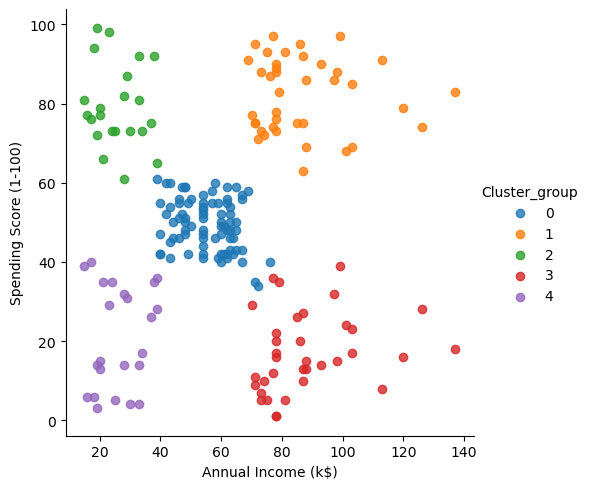

In [40]:
facet = sns.lmplot(
    data=supervised,
    x=supervised.columns[3],    # “Annual Income (k$)”
    y=supervised.columns[4],    # “Spending Score (1–100)”
    hue=supervised.columns[5],  # “Cluster_group” → different colors per cluster
    fit_reg=False,              # no regression line, just the raw points
    legend=True,                # show the legend
    legend_out=True             # position the legend outside the main plotting area
)

In [41]:
# Install seaborn for statistical data visualization
# (If you’re in a Conda environment, you could instead run:
#    conda install -c conda-forge seaborn
# )
!pip install seaborn